**Import Python Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


**Load the dataset**

In [8]:

file_path = "/content/online_retail_II.csv"
df = pd.read_csv(file_path, encoding='latin1')

print("Shape:", df.shape)
print(df.head())


Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


**Data Cleaning**

In [10]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
print("Columns:", df.columns.tolist())
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Customer_ID', 'InvoiceDate'])
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['Price']
print("Cleaned dataset shape:", df.shape)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']
Cleaned dataset shape: (335675, 9)


**Calculate RFM Metricst**

In [11]:
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
rfm = df.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                     # Monetary
}).reset_index()
rfm.rename(columns={'InvoiceDate': 'Recency',
                   'Invoice': 'Frequency',
                   'TotalPrice': 'Monetary'}, inplace=True) ,print(rfm.head())

   Customer_ID  Recency  Frequency  Monetary
0      12346.0      619          3     72.05
1      12347.0       96          5   3252.08
2      12348.0      221          1    367.00
3      12350.0      312          1    334.40
4      12352.0      275          4   1440.13


**Assign RFM Scores**

In [12]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Sum'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)
print(rfm.head())

   Customer_ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0      12346.0      619          3     72.05       1       3       1   
1      12347.0       96          5   3252.08       4       5       5   
2      12348.0      221          1    367.00       3       1       2   
3      12350.0      312          1    334.40       2       1       2   
4      12352.0      275          4   1440.13       3       4       4   

  RFM_Score  RFM_Sum  
0       131        5  
1       455       14  
2       312        6  
3       212        5  
4       344       11  


**Segment Customers**

In [13]:
def assign_segment(row):
    if row['RFM_Sum'] >= 12:
        return 'Champions'
    elif row['RFM_Sum'] >= 9:
        return 'Loyal Customers'
    elif row['RFM_Sum'] >= 6:
        return 'Potential Loyalists'
    elif row['RFM_Sum'] <= 3:
        return 'Lost/Hibernating'
    else:
        return 'Other'
rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print(rfm[['Customer_ID','RFM_Score','RFM_Sum','Segment']].head())


   Customer_ID RFM_Score  RFM_Sum              Segment
0      12346.0       131        5                Other
1      12347.0       455       14            Champions
2      12348.0       312        6  Potential Loyalists
3      12350.0       212        5                Other
4      12352.0       344       11      Loyal Customers


**Visualize Segments**

/tmp/ipython-input-2857466912.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


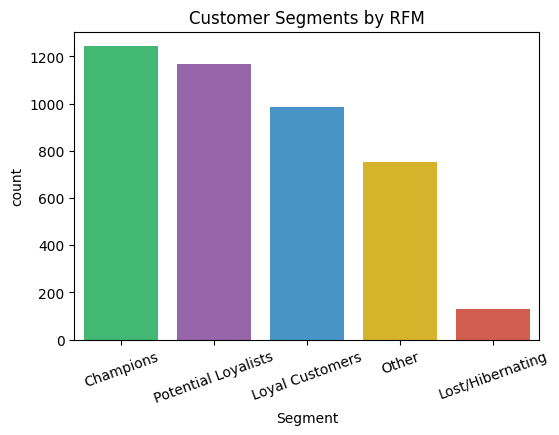

In [39]:
segment_colors = {
    "Champions": "#2ecc71",
    "Loyal Customers": "#3498db",
    "Potential Loyalists": "#9b59b6",
    "Lost/Hibernating": "#e74c3c",
    "Other": "#f1c40f"
}
plt.figure(figsize=(6,4))
sns.countplot(
    x='Segment',
    data=rfm,
    order=rfm['Segment'].value_counts().index,
    palette=segment_colors
)
plt.title('Customer Segments by RFM')
plt.xticks(rotation=20)
plt.show()


**Heatmap of R & F vs Monetary**

/tmp/ipython-input-4024985825.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rfm_pivot = rfm.pivot_table(index='F_Score', columns='R_Score', values='Monetary', aggfunc='mean')


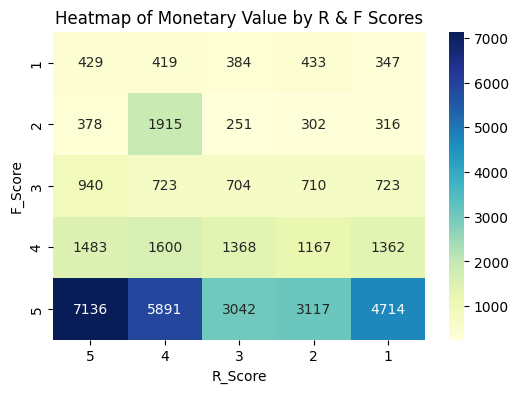

In [18]:
rfm_pivot = rfm.pivot_table(index='F_Score', columns='R_Score', values='Monetary', aggfunc='mean')

plt.figure(figsize=(6,4))
sns.heatmap(rfm_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap of Monetary Value by R & F Scores')
plt.show()


# Extra Effort

**Distribution of Recency, Frequency, Monetary**

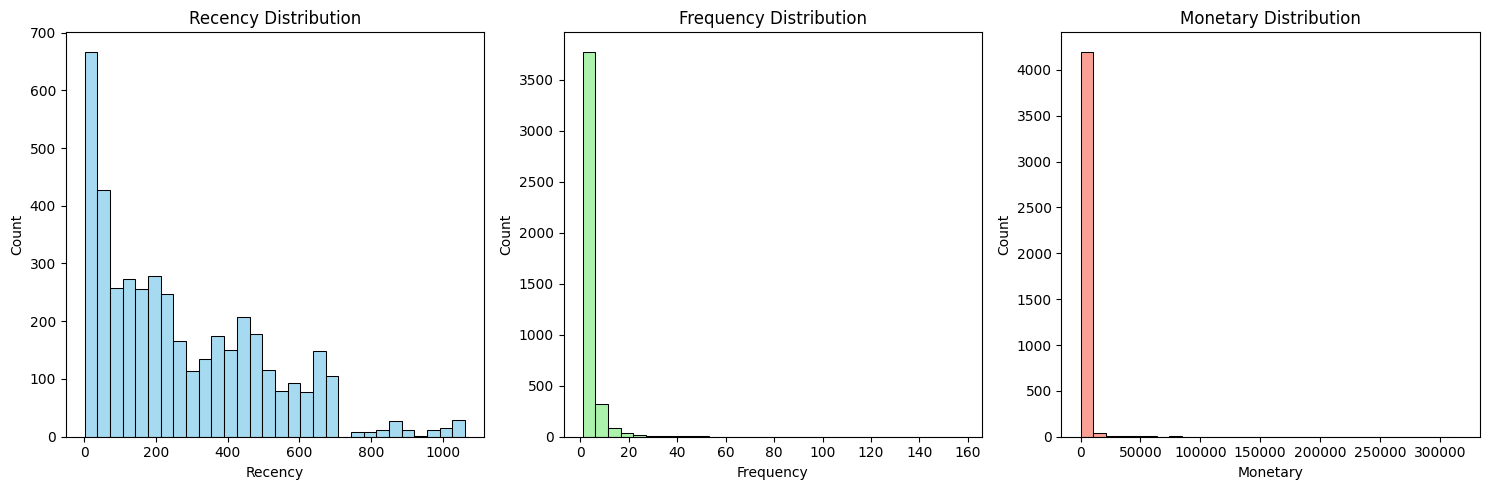

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("Recency Distribution")
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color="lightgreen")
axes[1].set_title("Frequency Distribution")
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color="salmon")
axes[2].set_title("Monetary Distribution")
plt.tight_layout()
plt.show()


**Average Monetary per Segment (Bar Chart)**

/tmp/ipython-input-1424082102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_avg.index, y=segment_avg.values, palette="viridis")


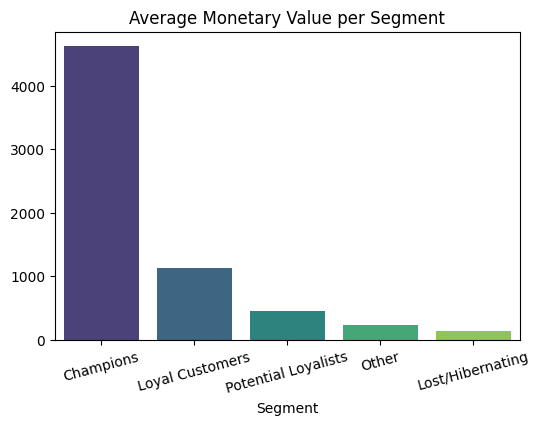

In [38]:
plt.figure(figsize=(6,4))
segment_avg = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
sns.barplot(x=segment_avg.index, y=segment_avg.values, palette="viridis")
plt.title("Average Monetary Value per Segment")
plt.xticks(rotation=15)
plt.show()


**KMeans Clustering Visualization (if clustering used)**

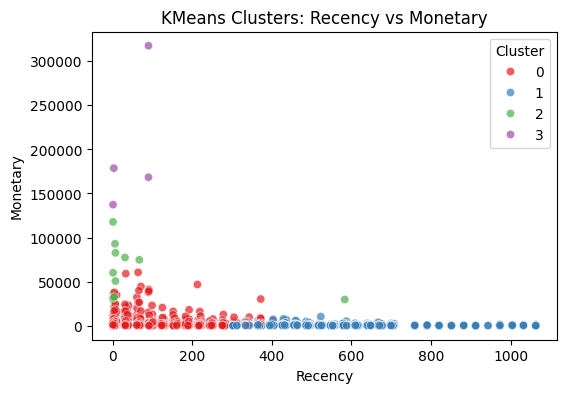

In [27]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

plt.figure(figsize=(6,4))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette="Set1", alpha=0.7)
plt.title("KMeans Clusters: Recency vs Monetary")
plt.show()


**Boxplot of Monetary by Segment**

/tmp/ipython-input-2997249186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


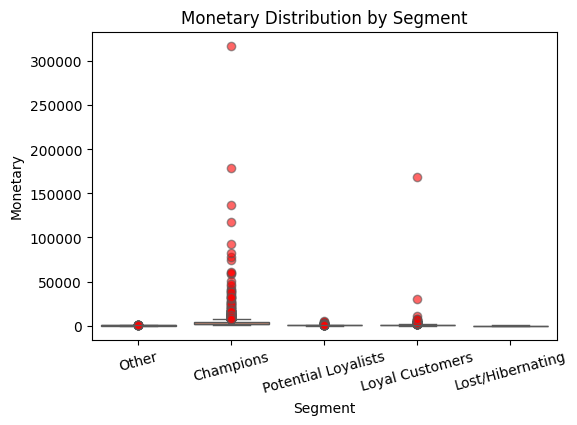

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Segment',
    y='Monetary',
    data=rfm,
    palette="Set2",   # boxes ke liye colors
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6)
)
plt.title("Monetary Distribution by Segment")
plt.xticks(rotation=15)
plt.show()